In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
stock_prices = pd.read_excel(
    "../data/raw/supporting/stock_prices.xlsx"
)

print(stock_prices.shape)
stock_prices.head()

(5520, 9)


,id,company_id,date,open_price,high_price,low_price,close_price,volume,adjusted_close
0,1,ABB,2020-01-01,1958.61,2150.53,1835.28,1964.30,26184368,1964.30
1,2,ABB,2020-02-01,2177.03,2192.92,1931.08,2165.21,1668316,2165.21
2,3,ABB,2020-03-01,2221.26,2440.28,1995.23,2198.78,20578107,2198.78
3,4,ABB,2020-04-01,1932.02,2027.44,1740.12,1958.56,14558597,1958.56
4,5,ABB,2020-05-01,2089.00,2290.96,1878.23,2085.72,44638694,2085.72


In [3]:
stock_prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 5520 entries, 0 to 5519
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              5520 non-null   int64  
 1   company_id      5520 non-null   str    
 2   date            5520 non-null   str    
 3   open_price      5520 non-null   float64
 4   high_price      5520 non-null   float64
 5   low_price       5520 non-null   float64
 6   close_price     5520 non-null   float64
 7   volume          5520 non-null   int64  
 8   adjusted_close  5520 non-null   float64
dtypes: float64(5), int64(2), str(2)
memory usage: 388.3 KB


In [4]:
stock_prices["date"] = pd.to_datetime(
    stock_prices["date"]
)

stock_prices.dtypes

id                         int64
company_id                   str
date              datetime64[us]
open_price               float64
high_price               float64
low_price                float64
close_price              float64
volume                     int64
adjusted_close           float64
dtype: object

In [5]:
abb = stock_prices[
    stock_prices["company_id"] == "ABB"
]

abb.head()

,id,company_id,date,open_price,high_price,low_price,close_price,volume,adjusted_close
0,1,ABB,2020-01-01,1958.61,2150.53,1835.28,1964.30,26184368,1964.30
1,2,ABB,2020-02-01,2177.03,2192.92,1931.08,2165.21,1668316,2165.21
2,3,ABB,2020-03-01,2221.26,2440.28,1995.23,2198.78,20578107,2198.78
3,4,ABB,2020-04-01,1932.02,2027.44,1740.12,1958.56,14558597,1958.56
4,5,ABB,2020-05-01,2089.00,2290.96,1878.23,2085.72,44638694,2085.72


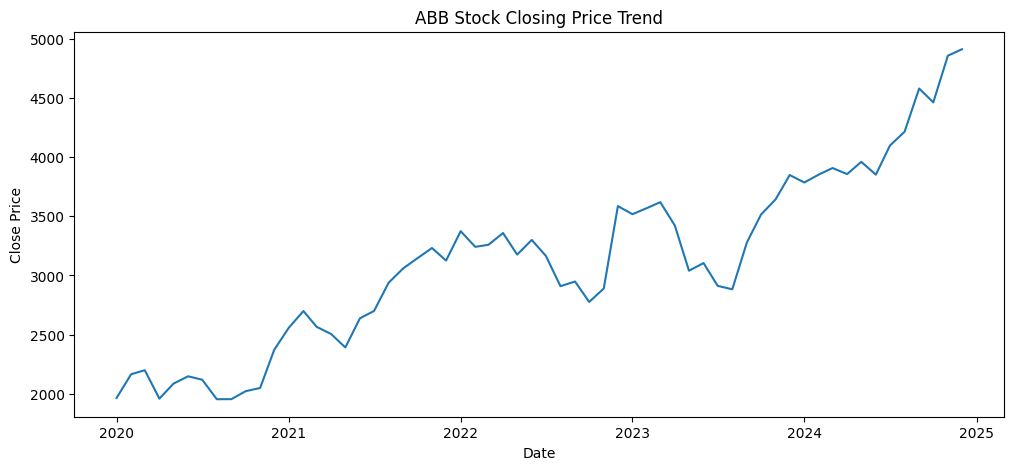

In [6]:
plt.figure(figsize=(12,5))

plt.plot(
    abb["date"],
    abb["close_price"]
)

plt.title("ABB Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

In [7]:
top_volume = (
    stock_prices.groupby("company_id")
    ["volume"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_volume

company_id
AXISBANK      1766944763
SBILIFE       1731304836
GAIL          1696024775
TATASTEEL     1688033145
ICICIBANK     1687899504
IOC           1680612954
NESTLEIND     1678989132
ONGC          1664740549
PIDILITIND    1662894362
PFC           1659124665
Name: volume, dtype: int64

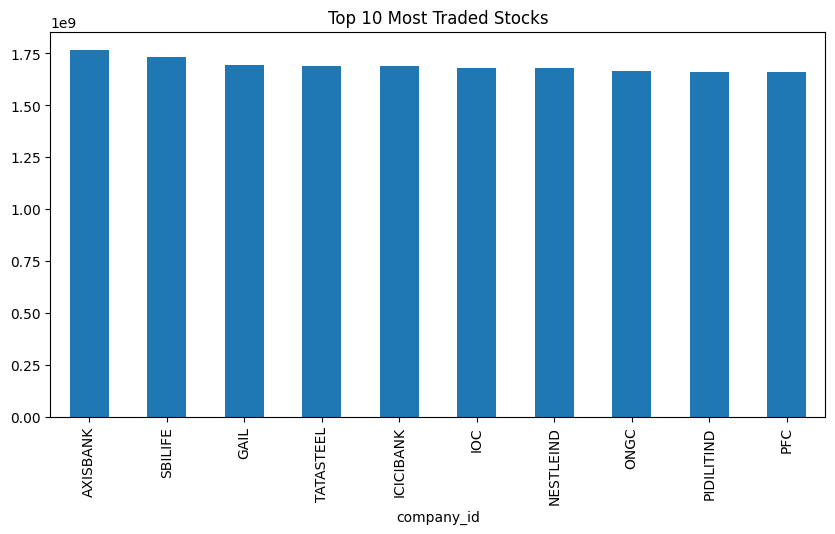

In [8]:
plt.figure(figsize=(10,5))

top_volume.plot(kind="bar")

plt.title("Top 10 Most Traded Stocks")

plt.show()

In [9]:
highest_price = (
    stock_prices.groupby("company_id")
    ["high_price"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

highest_price

company_id
ITC           16599.39
IRCTC         12359.92
BAJAJ-AUTO    12157.01
GRASIM        11958.81
JIOFIN        11416.70
ONGC          10851.30
NHPC          10763.50
JSWENERGY     10365.57
ADANIENT      10276.65
JINDALSTEL     9924.36
Name: high_price, dtype: float64